## phase 4

In [1]:
import logging
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)


In [2]:
FEATURE_CSV_PATH = Path("feature2.csv")

svm_model_path = Path("svm_manual_scaled.pkl")
dt_model_path = Path("dt_phase3.pkl")

TEST_SIZE = 0.2
RANDOM_STATE = 42 


In [3]:
logging.info("Loading features from %s", FEATURE_CSV_PATH.resolve())
df = pd.read_csv(FEATURE_CSV_PATH)

if "label" in df.columns:
    label_col = "label"
else:
    label_col = df.columns[2]  # fallback

y = df[label_col].astype(int).values

feature_columns = df.columns[3:]
feature_columns = [col for col in feature_columns if col != "split"]

# Keep as DataFrame to preserve feature names for the models
X = df[feature_columns].astype("float32")

logging.info("Feature matrix shape: %s", X.shape)
logging.info("Labels shape: %s", y.shape)

label_indices = df[label_col].astype(int).values
class_names_col = df.iloc[:, 1].astype(str).values

label_to_name = {}
for lbl, name in zip(label_indices, class_names_col):
    label_to_name[int(lbl)] = name

num_classes = len(set(label_to_name.keys()))
target_names = [label_to_name[i] for i in range(num_classes)]

logging.info("Detected %d classes.", num_classes)
logging.info("Label -> class name mapping: %s", label_to_name)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
 )

logging.info("X_train: %s, X_test: %s", X_train.shape, X_test.shape)
logging.info("y_train: %s, y_test: %s", y_train.shape, y_test.shape)

2025-12-11 23:19:41,185 [INFO] Loading features from E:\7\computational Intelligence\projects\project2\project2\feature2.csv
2025-12-11 23:19:48,745 [INFO] Feature matrix shape: (26179, 1865)
2025-12-11 23:19:48,746 [INFO] Labels shape: (26179,)
2025-12-11 23:19:48,754 [INFO] Detected 10 classes.
2025-12-11 23:19:48,755 [INFO] Label -> class name mapping: {0: 'butterfly', 1: 'cat', 2: 'chicken', 3: 'cow', 4: 'dog', 5: 'elephant', 6: 'horse', 7: 'sheep', 8: 'spider', 9: 'squirrel'}
2025-12-11 23:19:48,745 [INFO] Feature matrix shape: (26179, 1865)
2025-12-11 23:19:48,746 [INFO] Labels shape: (26179,)
2025-12-11 23:19:48,754 [INFO] Detected 10 classes.
2025-12-11 23:19:48,755 [INFO] Label -> class name mapping: {0: 'butterfly', 1: 'cat', 2: 'chicken', 3: 'cow', 4: 'dog', 5: 'elephant', 6: 'horse', 7: 'sheep', 8: 'spider', 9: 'squirrel'}
2025-12-11 23:19:48,918 [INFO] X_train: (20943, 1865), X_test: (5236, 1865)
2025-12-11 23:19:48,919 [INFO] y_train: (20943,), y_test: (5236,)
2025-12-11 

In [4]:
# Cell 4: load tuned models from phase 3

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def _unwrap_model(loaded_obj, model_label):
    """
    Return an object with predict method from saved checkpoint.
    If loaded_obj is a dict with 'model' and 'scaler', wrap them in a Pipeline.
    """
    if hasattr(loaded_obj, "predict"):
        return loaded_obj

    if isinstance(loaded_obj, dict):
        # Handle {'model': ..., 'scaler': ...} format from phase 3
        if "model" in loaded_obj and "scaler" in loaded_obj:
            scaler = loaded_obj["scaler"]
            model = loaded_obj["model"]
            if hasattr(model, "predict") and hasattr(scaler, "transform"):
                logging.info("Wrapping %s with scaler in a Pipeline", model_label)
                return Pipeline([("scaler", scaler), ("model", model)])

        candidate_keys = [
            "best_model",
            "best_estimator_",
            "best_estimator",
            "model",
            "estimator",
            "pipeline",
        ]
        for key in candidate_keys:
            candidate = loaded_obj.get(key)
            if hasattr(candidate, "predict"):
                logging.info("Unwrapped %s from key '%s'", model_label, key)
                return candidate

    raise AttributeError(f"Saved {model_label} does not provide a predict method.")

logging.info("Loading tuned SVM model from %s", svm_model_path.resolve())
svm_loaded = joblib.load(svm_model_path)
best_svm = _unwrap_model(svm_loaded, "SVM")

logging.info("Loading tuned Decision Tree model from %s", dt_model_path.resolve())
dt_loaded = joblib.load(dt_model_path)
best_dt = _unwrap_model(dt_loaded, "DecisionTree")

logging.info("Loaded models: SVM type=%s, DT type=%s", type(best_svm), type(best_dt))

2025-12-11 23:19:48,935 [INFO] Loading tuned SVM model from E:\7\computational Intelligence\projects\project2\project2\svm_manual_scaled.pkl
2025-12-11 23:19:49,107 [INFO] Wrapping SVM with scaler in a Pipeline
2025-12-11 23:19:49,109 [INFO] Loading tuned Decision Tree model from E:\7\computational Intelligence\projects\project2\project2\dt_phase3.pkl
2025-12-11 23:19:49,107 [INFO] Wrapping SVM with scaler in a Pipeline
2025-12-11 23:19:49,109 [INFO] Loading tuned Decision Tree model from E:\7\computational Intelligence\projects\project2\project2\dt_phase3.pkl
2025-12-11 23:19:49,159 [INFO] Loaded models: SVM type=<class 'sklearn.pipeline.Pipeline'>, DT type=<class 'sklearn.tree._classes.DecisionTreeClassifier'>
2025-12-11 23:19:49,159 [INFO] Loaded models: SVM type=<class 'sklearn.pipeline.Pipeline'>, DT type=<class 'sklearn.tree._classes.DecisionTreeClassifier'>


In [5]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, target_names=None):
    """
    مدل داده‌شده را روی train و test ارزیابی می‌کند و
    accuracy، precision_macro، recall_macro، f1_macro و ماتریس درهم‌ریختگی را برمی‌گرداند.
    """
    logging.info("======================================")
    logging.info("Evaluating model: %s", model_name)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    metrics = {}

    for split_name, y_true, y_pred in [
        ("train", y_train, y_train_pred),
        ("test", y_test, y_test_pred),
    ]:
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        logging.info(
            "[%s][%s] accuracy: %.4f | precision_macro: %.4f | recall_macro: %.4f | f1_macro: %.4f",
            model_name,
            split_name,
            acc,
            prec,
            rec,
            f1,
        )

        report = classification_report(
            y_true,
            y_pred,
            target_names=target_names,
            digits=4,
            zero_division=0,
        )

        print(f"\n==== {model_name} - {split_name} classification report ====\n")
        print(report)

        metrics[split_name] = {
            "accuracy": acc,
            "precision_macro": prec,
            "recall_macro": rec,
            "f1_macro": f1,
            "confusion_matrix": cm,
            "classification_report": report,
        }

    return metrics


In [6]:
svm_metrics = evaluate_model(
    best_svm,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="SVM",
    target_names=target_names,
)

dt_metrics = evaluate_model(
    best_dt,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="DecisionTree",
    target_names=target_names,
)

summary_rows = []
for model_name, m in [("SVM", svm_metrics), ("DecisionTree", dt_metrics)]:
    for split_name in ["train", "test"]:
        row = {
            "model": model_name,
            "split": split_name,
            "accuracy": m[split_name]["accuracy"],
            "precision_macro": m[split_name]["precision_macro"],
            "recall_macro": m[split_name]["recall_macro"],
            "f1_macro": m[split_name]["f1_macro"],
        }
        summary_rows.append(row)

metrics_df = pd.DataFrame(summary_rows)
metrics_df


2025-12-11 23:19:49,188 [INFO] ======================================
2025-12-11 23:19:49,188 [INFO] Evaluating model: SVM
2025-12-11 23:19:49,188 [INFO] Evaluating model: SVM
2025-12-11 23:32:51,836 [INFO] [SVM][train] accuracy: 0.9985 | precision_macro: 0.9987 | recall_macro: 0.9982 | f1_macro: 0.9985
2025-12-11 23:32:51,855 [INFO] [SVM][test] accuracy: 0.6503 | precision_macro: 0.6504 | recall_macro: 0.6015 | f1_macro: 0.6192
2025-12-11 23:32:51,865 [INFO] ======================================
2025-12-11 23:32:51,866 [INFO] Evaluating model: DecisionTree
2025-12-11 23:32:51,950 [INFO] [DecisionTree][train] accuracy: 0.5160 | precision_macro: 0.5210 | recall_macro: 0.4489 | f1_macro: 0.4684
2025-12-11 23:32:51,970 [INFO] [DecisionTree][test] accuracy: 0.3535 | precision_macro: 0.3320 | recall_macro: 0.2996 | f1_macro: 0.3063



==== SVM - train classification report ====

              precision    recall  f1-score   support

   butterfly     1.0000    0.9994    0.9997      1690
         cat     1.0000    0.9955    0.9977      1334
     chicken     0.9916    0.9996    0.9956      2478
         cow     1.0000    0.9980    0.9990      1493
         dog     0.9997    0.9987    0.9992      3890
    elephant     1.0000    0.9983    0.9991      1157
       horse     1.0000    0.9990    0.9995      2098
       sheep     0.9966    0.9979    0.9973      1456
      spider     0.9990    0.9992    0.9991      3857
    squirrel     1.0000    0.9966    0.9983      1490

    accuracy                         0.9985     20943
   macro avg     0.9987    0.9982    0.9985     20943
weighted avg     0.9985    0.9985    0.9985     20943


==== SVM - test classification report ====

              precision    recall  f1-score   support

   butterfly     0.7287    0.6682    0.6972       422
         cat     0.5631    0.3473    0.42

,model,split,accuracy,precision_macro,recall_macro,f1_macro
0,SVM,train,0.998520,0.998687,0.998234,0.998458
1,SVM,test,0.650306,0.650393,0.601483,0.619203
2,DecisionTree,train,0.516020,0.521037,0.448911,0.468382
3,DecisionTree,test,0.353514,0.332024,0.299552,0.306279


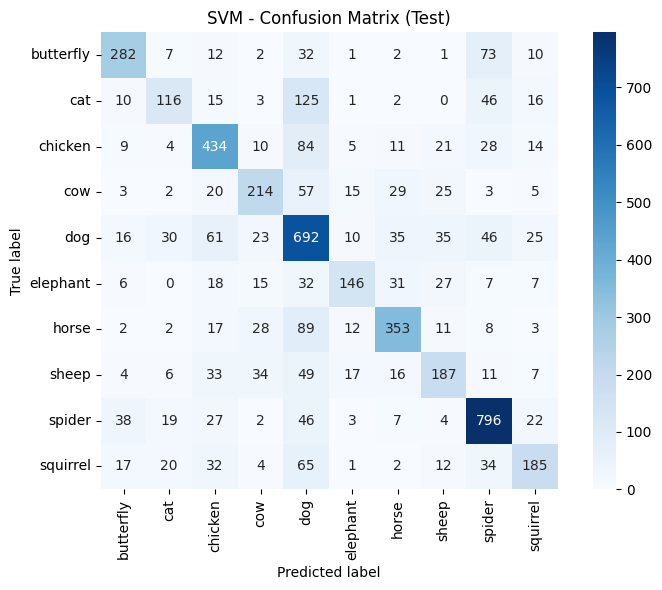

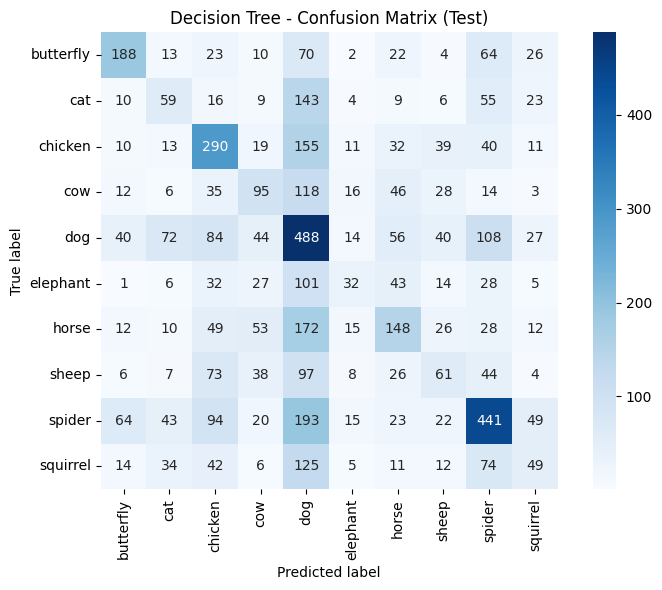

In [7]:
def plot_confusion_matrix(cm, class_labels, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_labels,
        yticklabels=class_labels,
        cmap="Blues",
        cbar=True,
        square=True,
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

cm_svm_test = svm_metrics["test"]["confusion_matrix"]
cm_dt_test = dt_metrics["test"]["confusion_matrix"]

plot_confusion_matrix(cm_svm_test, target_names, "SVM - Confusion Matrix (Test)")
plot_confusion_matrix(cm_dt_test, target_names, "Decision Tree - Confusion Matrix (Test)")


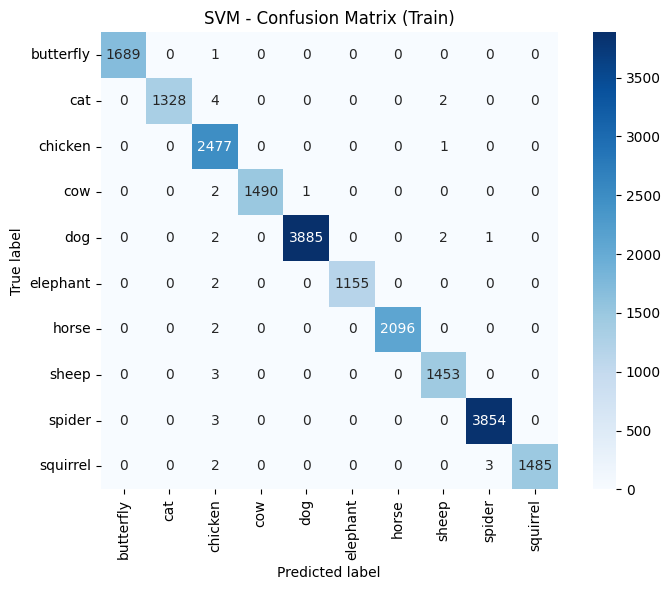

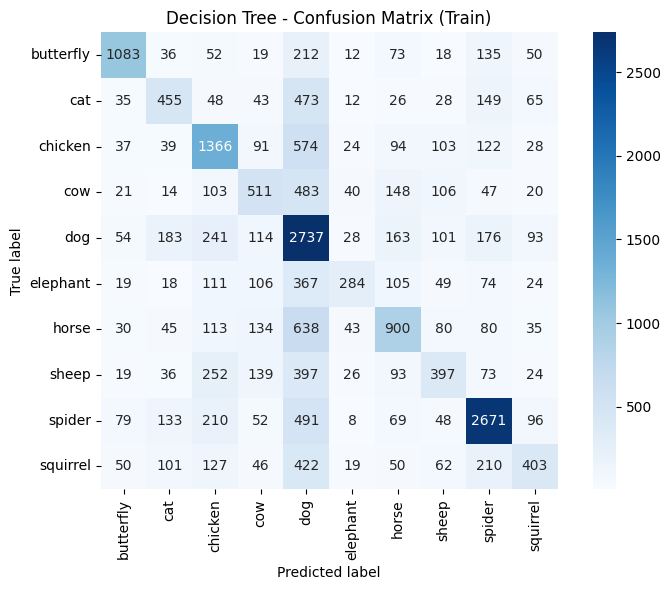

In [8]:
cm_svm_train = svm_metrics["train"]["confusion_matrix"]
cm_dt_train = dt_metrics["train"]["confusion_matrix"]

plot_confusion_matrix(cm_svm_train, target_names, "SVM - Confusion Matrix (Train)")
plot_confusion_matrix(cm_dt_train, target_names, "Decision Tree - Confusion Matrix (Train)")


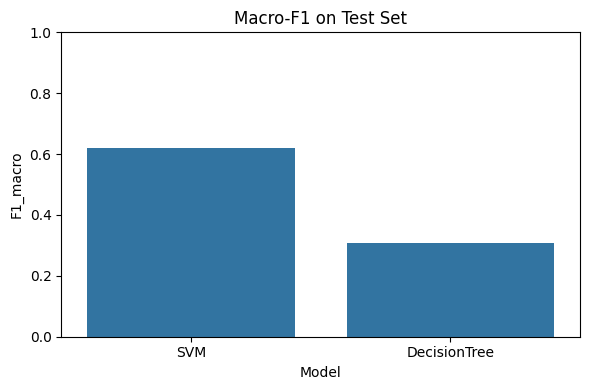

In [9]:
test_df = metrics_df[metrics_df["split"] == "test"].copy()

plt.figure(figsize=(6, 4))
sns.barplot(
    data=test_df,
    x="model",
    y="f1_macro",
)
plt.title("Macro-F1 on Test Set")
plt.ylabel("F1_macro")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
